In [6]:
import numpy as np
import torch
from __init__ import PRP
import sys
from glob import glob
import einops
sys.path.append(f'{PRP}/Results/analysis_scripts/')
from metrics import get_density_at_surface_tensor
from sklearn.cluster import KMeans
from ShapeChecker import ShapeCheck
import seaborn as sns

In [23]:
base = '/Volumes/LoCe/oceandata/models/dino-fusion/Publication-Blandine/generated_npy_files/'
print([x.replace(base, '') for x in glob(base + '*')])
name = 'chamon_C2_clean'

['constraint_TS_clean', 'no_constraint_clean', 'chamon_C2_clean', 'chamon_C1_clean', 'data']


In [24]:
soce = torch.tensor(np.load(f'{base}/{name}/soce.npy'))
toce = torch.tensor(np.load(f'{base}/{name}/toce.npy'))
if soce.ndim == 3 : 
    soce = soce[None]
    toce = toce[None]

In [25]:
p = 5
density = get_density_at_surface_tensor(toce, soce)[:, :-1, 5:-5, 5:-5]
sc = ShapeCheck(density.shape, 'b k i j')
density_flat = sc.rearrange(density, 'b k i j -> b (i j) k')[0] # take first profile of the batch

/var/folders/v0/69j0mqn17s50r4rf2hscwsyw0000gp/T/ipykernel_70970/2203624443.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', n_clusters)


<Axes: >

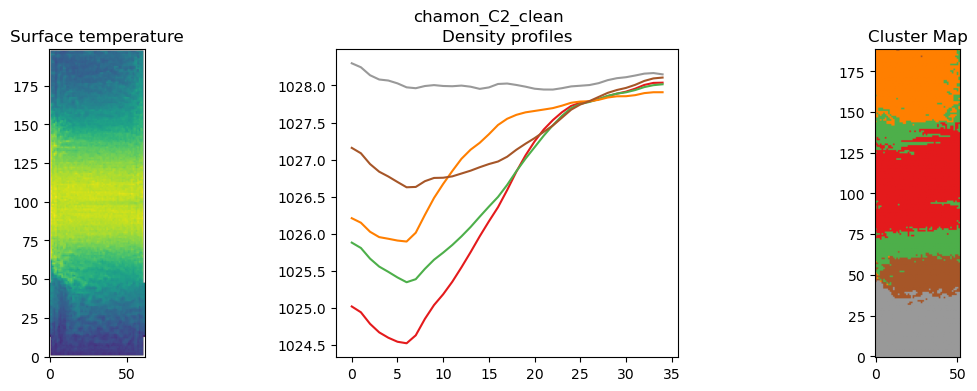

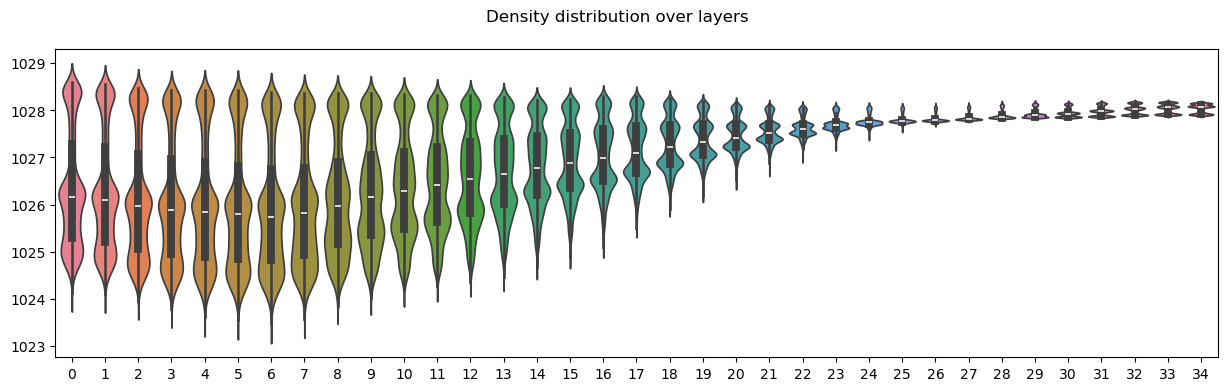

In [26]:
km = KMeans(5)
clusters = km.fit_predict(density_flat)

# --- Sort clusters by surface density and relabel ---
surface_density = km.cluster_centers_[:, 0]          # "surface" value for each cluster
order = np.argsort(surface_density)                  # indices of clusters sorted by surface density

# Build mapping old_label -> new_label such that new_label encodes sorted order
old_to_new = np.empty_like(order)
old_to_new[order] = np.arange(len(order))

# Apply mapping to labels and centers
clusters_sorted = old_to_new[clusters]               # relabeled cluster IDs
centers_sorted = km.cluster_centers_[order]          # centers in increasing surface density order

# From here on, *only* use centers_sorted and clusters_sorted
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(f'{name}')
axs[0].set_title('Surface temperature')
axs[0].imshow(toce[0, 0])

n_clusters = km.n_clusters  # or 8
cmap = plt.cm.get_cmap('Set1', n_clusters)

# --- Line plot with colors following sorted order ---
axs[1].set_title('Density profiles')
axs[1].set_prop_cycle(color=[cmap(i) for i in range(n_clusters)])
axs[1].plot(centers_sorted.T)   # centers are already ordered by surface density

# --- Cluster map with same cmap/index convention ---
axs[2].set_title('Cluster Map')
cluster_map = sc.rearrange(clusters_sorted, '(i j) -> i j')
axs[2].imshow(
    cluster_map,
    cmap=cmap,
    vmin=0,
    vmax=n_clusters - 1,
)

fig, ax = plt.subplots(1, 1, figsize=(15, 4))
fig.suptitle('Density distribution over layers')
sns.violinplot(density_flat[:], ax=ax)
